# Laboratorium 6: Od wyników do modelu gotowego do użycia

Zbiór danych: *European Top Leagues Player Stats 25-26* (Kaggle).

Łączymy preprocessing, modelowanie, interpretację i proste kontrole jakości.

**Spis treści:**
1. Wczytanie i przygotowanie danych
2. Definicja zadania ML
3. Pipeline z ColumnTransformer
4. Baseline vs Pipeline — porównanie
5. Interpretowalność — współczynniki modelu
6. Fairness z IBM AI Fairness 360
7. Check driftu — test KS
8. Symulacja monitoringu driftu
9. Szablon raportu

## Cele
- zbudować pipeline z `ColumnTransformer`,
- porównać model bazowy i model z preprocessingiem,
- obejrzeć znaczenie cech,
- przeprowadzić analizę fairness (IBM AIF360) względem czasu gry zawodnika,
- zrobić prosty check na przesunięcie danych i jakość predykcji,
- przygotować krótki szablon raportu.

## Importy

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from aif360.metrics import ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(42)

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


## 1. Wczytanie i przygotowanie danych

In [2]:
DATA_DIR = Path("data/13")

profiles_df = pd.read_csv(DATA_DIR / "all_player_profiles.csv")
stats_df    = pd.read_csv(DATA_DIR / "all_player_stats.csv")

df = profiles_df.merge(stats_df, on=["player_id", "league"], how="inner")
print(f"Profiles: {len(profiles_df)}, Stats: {len(stats_df)}, Merged: {len(df)}")

# filtr minimum 600 minut — analogicznie do main.ipynb
df = df[df["minutes_played"] >= 600].reset_index(drop=True)
print(f"Po filtrze minutes_played >= 600: {len(df)} zawodników")

per90_cols = ["goals", "assists", "tackles", "interceptions", "saves",
              "total_shots", "shots_on_target", "expected_goals", "expected_assists"]
for col in per90_cols:
    df[f"{col}_per90"] = df[col] * 90 / df["minutes_played"]

df.head()

Profiles: 4740, Stats: 3749, Merged: 3749
Po filtrze minutes_played >= 600: 2580 zawodników


,player_id,name,league,position,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves,goals_per90,assists_per90,tackles_per90,interceptions_per90,saves_per90,total_shots_per90,shots_on_target_per90,expected_goals_per90,expected_assists_per90
0,804508,Viktor Gyökeres,Premier League,F,61000000.0,30,24,1997,12,0,10.3733,1.773005,6.573333,47,18,5,0,6,1,0,0.540811,0.000000,0.270406,0.045068,0.0,2.118177,0.811217,0.467500,0.079905
1,934235,Bukayo Saka,Premier League,F,126000000.0,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0,0.269865,0.134933,1.619190,0.629685,0.0,2.833583,1.169415,0.314577,0.259158
2,922573,Gabriel Martinelli,Premier League,F,42000000.0,26,10,906,1,3,3.3793,0.999809,6.607692,25,10,2,0,10,0,0,0.099338,0.298013,0.993377,0.000000,0.0,2.483444,0.993377,0.335692,0.099319
3,135666,Leandro Trossard,Premier League,F,21000000.0,27,18,1721,5,5,4.8222,2.685569,6.859259,44,11,1,0,25,8,0,0.261476,0.261476,1.307379,0.418361,0.0,2.300988,0.575247,0.252178,0.140442
4,547410,Martin Ødegaard,Premier League,M,71000000.0,20,13,1078,1,5,1.0108,2.924704,6.995000,20,7,0,0,17,7,0,0.083488,0.417440,1.419295,0.584416,0.0,1.669759,0.584416,0.084390,0.244178


## 2. Definicja zadania ML

**Target binarny:** `is_high_value` — czy wartość rynkowa zawodnika przekracza medianę.

**Atrybut chroniony (fairness):** `high_minutes` — czy zawodnik rozegrał powyżej mediany minut. Sprawdzamy, czy model nie faworyzuje zawodników z dużą liczbą minut niezależnie od ich umiejętności.

In [4]:
# pomijamy 7 zawodników z brakującą wartością rynkową
df = df.dropna(subset=["market_value"]).reset_index(drop=True)

market_median  = df["market_value"].median()
minutes_median = df["minutes_played"].median()

df["is_high_value"] = (df["market_value"] > market_median).astype(int)
df["high_minutes"]  = (df["minutes_played"] > minutes_median).astype(int)

print(f"Mediana market_value: {market_median:,.0f} EUR")
print(f"Mediana minutes_played: {minutes_median:.0f}")
print(f"is_high_value rozkład: {df['is_high_value'].value_counts().to_dict()}")
print(f"high_minutes rozkład: {df['high_minutes'].value_counts().to_dict()}")

Mediana market_value: 5,200,000 EUR
Mediana minutes_played: 1533
is_high_value rozkład: {0: 1300, 1: 1273}
high_minutes rozkład: {0: 1289, 1: 1284}


In [5]:
numeric_features = [
    "goals_per90", "assists_per90", "expected_goals_per90", "expected_assists_per90",
    "rating", "appearances", "minutes_played", "total_shots_per90", "shots_on_target_per90",
    "tackles_per90", "interceptions_per90", "saves_per90", "yellow_cards",
]
categorical_features = ["position", "league"]

X = df[numeric_features + categorical_features]
y = df["is_high_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features: {categorical_features}")

Train: 1929, Test: 644
Numeric features (13): ['goals_per90', 'assists_per90', 'expected_goals_per90', 'expected_assists_per90', 'rating', 'appearances', 'minutes_played', 'total_shots_per90', 'shots_on_target_per90', 'tackles_per90', 'interceptions_per90', 'saves_per90', 'yellow_cards']
Categorical features: ['position', 'league']


## 3. Pipeline z ColumnTransformer

In [6]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

model.fit(X_train, y_train)

pred  = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=["low value", "high value"]))

accuracy: 0.765527950310559
              precision    recall  f1-score   support

   low value       0.76      0.78      0.77       325
  high value       0.77      0.75      0.76       319

    accuracy                           0.77       644
   macro avg       0.77      0.77      0.77       644
weighted avg       0.77      0.77      0.77       644



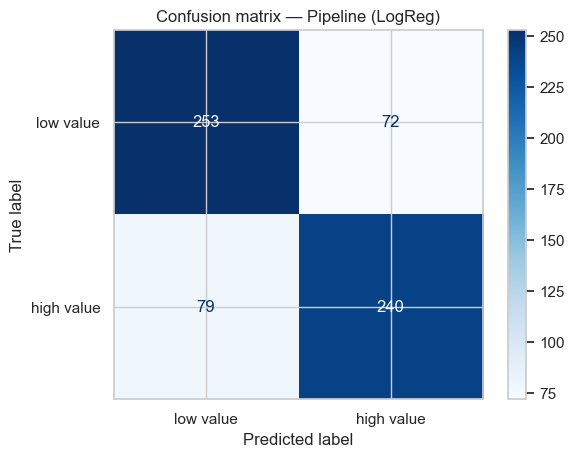

In [6]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["low value", "high value"]).plot(cmap="Blues")
plt.title("Confusion matrix — Pipeline (LogReg)")
plt.show()

## 4. Baseline vs Pipeline — porównanie

Model bazowy: `LogisticRegression` tylko z imputacją, bez skalowania, tylko cechy numeryczne, `max_iter=2` (celowo mała wartość jak w instrukcji — brak zbieżności).

Brak skalowania sprawia, że algorytm gradient descent słabo się zbiega — widoczny wpływ na accuracy.

In [7]:
X_train_num = X_train[numeric_features]
X_test_num  = X_test[numeric_features]

baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LogisticRegression(max_iter=2, random_state=42)),  # celowo mała wartość max_iter
])
baseline.fit(X_train_num, y_train)
pred_base = baseline.predict(X_test_num)

acc_base     = accuracy_score(y_test, pred_base)
acc_pipeline = accuracy_score(y_test, pred)

comparison = pd.DataFrame({
    "model":    ["Baseline (brak skalowania, max_iter=2)", "Pipeline (scaling + OHE, max_iter=1000)"],
    "features": ["tylko numeryczne", "numeryczne + position + league"],
    "accuracy": [acc_base, acc_pipeline],
})
comparison

/Users/aleklyskawa/Desktop/FootballPlayersAnalysis/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,features,accuracy
0,"Baseline (brak skalowania, max_iter=2)",tylko numeryczne,0.495342
1,"Pipeline (scaling + OHE, max_iter=1000)",numeryczne + position + league,0.765528


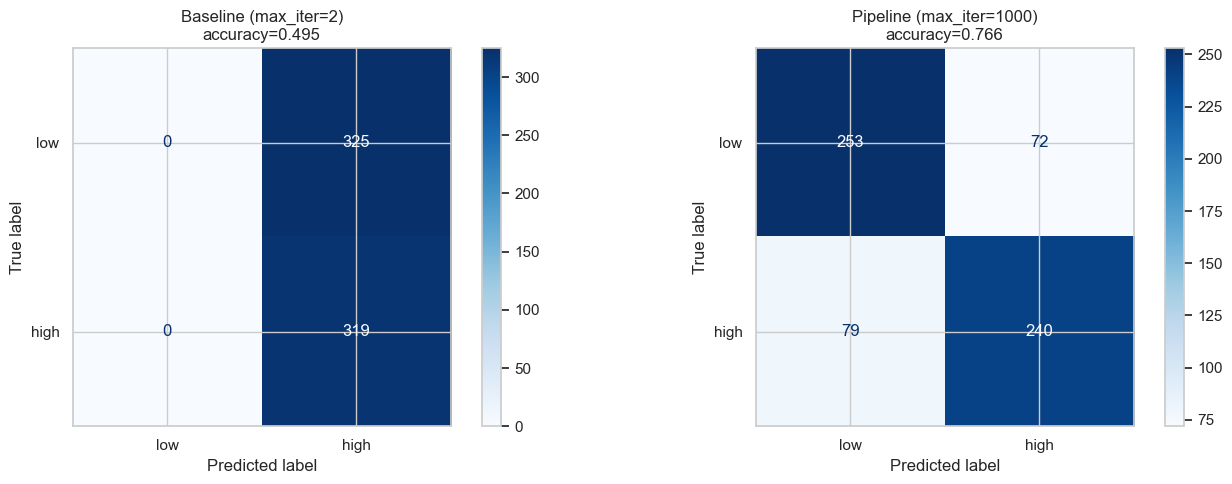

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, preds) in zip(axes, [
    ("Baseline (max_iter=2)", pred_base),
    ("Pipeline (max_iter=1000)", pred),
]):
    cm_plot = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm_plot, display_labels=["low", "high"]).plot(cmap="Blues", ax=ax)
    ax.set_title(f"{name}\naccuracy={accuracy_score(y_test, preds):.3f}")

plt.tight_layout()
plt.show()

## 5. Interpretowalność — współczynniki modelu

Wyciągamy współczynniki logistycznej regresji z pełnego pipeline'u. Większa wartość bezwzględna = większy wpływ cechy na predykcję.

Nazwy cech po OneHotEncoding dla `position` i `league` są automatycznie pobierane z enkodera.

In [9]:
ohe_names = list(
    model.named_steps["preprocess"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + ohe_names

coefs = pd.Series(
    model.named_steps["clf"].coef_[0],
    index=all_feature_names
).sort_values(key=np.abs, ascending=False)

coefs.head(15)

league_Premier League    2.972427
league_Eredivisie       -1.804377
league_Super Lig        -1.550761
position_G               1.314765
league_Liga Portugal    -1.287231
league_Serie A           0.787639
position_F              -0.739479
saves_per90             -0.692654
rating                   0.687011
league_Bundesliga        0.640669
position_M              -0.364876
expected_goals_per90     0.345493
assists_per90            0.256386
league_Ligue 1           0.231483
minutes_played           0.204153
dtype: float64

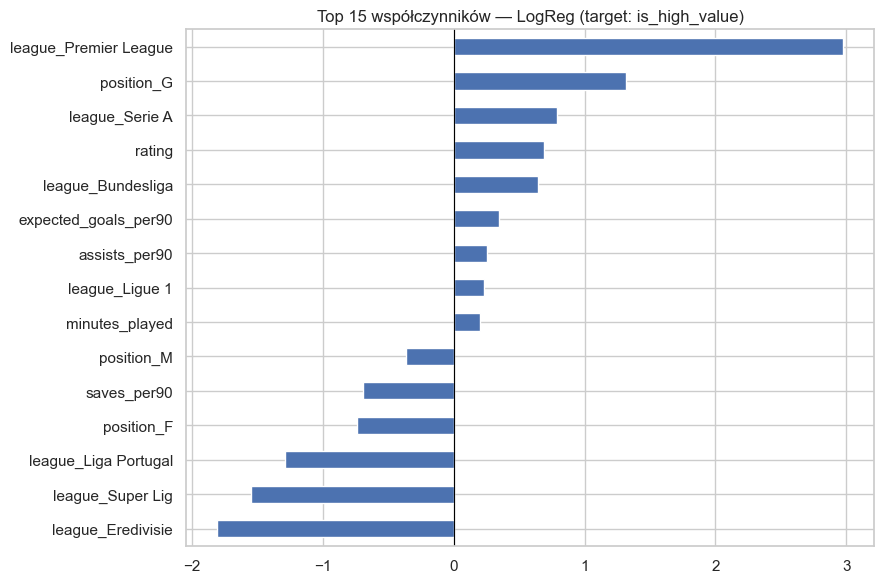

In [10]:
coefs.head(15).sort_values().plot(kind="barh", figsize=(9, 6))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 współczynników — LogReg (target: is_high_value)")
plt.tight_layout()
plt.show()

## 6. Fairness z IBM AI Fairness 360

Wprowadzenie: https://fairlearn.org/main/user_guide/fairness_in_machine_learning.html

**Pytanie:** Czy model systematycznie różnicuje predykcje dla zawodników z dużą vs. małą liczbą minut (`high_minutes`), niezależnie od faktycznych umiejętności?

- **Privileged group** (`high_minutes = 1`): zawodnicy z `minutes_played > mediana`
- **Unprivileged group** (`high_minutes = 0`): zawodnicy z `minutes_played <= mediana`
- **Favorable label** = 1 (is_high_value = 1, czyli predykcja 'wysoka wartość')

In [11]:
# wypełniamy expected_goals_per90 medianą z train (AIF360 nie akceptuje NaN)
xg_train_median = X_train["expected_goals_per90"].median()

df_fair = X_test[numeric_features].copy()
df_fair["expected_goals_per90"] = df_fair["expected_goals_per90"].fillna(xg_train_median)
df_fair["target"]       = y_test.values
df_fair["high_minutes"] = df.loc[X_test.index, "high_minutes"].values
df_fair["prediction"]   = pred

base_dataset = BinaryLabelDataset(
    df=df_fair,
    label_names=["target"],
    protected_attribute_names=["high_minutes"],
    favorable_label=1,
    unfavorable_label=0,
)
pred_df = df_fair.copy()
pred_df["target"] = df_fair["prediction"]
pred_dataset = BinaryLabelDataset(
    df=pred_df,
    label_names=["target"],
    protected_attribute_names=["high_minutes"],
    favorable_label=1,
    unfavorable_label=0,
)

metric = ClassificationMetric(
    base_dataset, pred_dataset,
    unprivileged_groups=[{"high_minutes": 0}],
    privileged_groups=[{"high_minutes": 1}],
)

fair_metrics = {
    "demographic_parity_diff":  metric.mean_difference(),
    "average_odds_diff":        metric.average_odds_difference(),
    "statistical_parity_diff": metric.statistical_parity_difference(),
}
fair_metrics

{'demographic_parity_diff': np.float64(-0.18974680491921875),
 'average_odds_diff': np.float64(-0.11846226022156726),
 'statistical_parity_diff': np.float64(-0.18974680491921875)}

Wartości powyżej pokazują różnicę w predykcjach między grupami:
- **`demographic_parity_diff`** bliskie 0 — model podobnie często przypisuje 'high value' obu grupom.
- **`average_odds_diff`** bliskie 0 — model ma podobną skuteczność (TPR i FPR) w obu grupach.
- Ujemna wartość oznacza, że **zawodnicy z mniejszą liczbą minut** (`high_minutes = 0`) są rzadziej predykowani jako 'high value' — model faworyzuje zawodników z dużą liczbą minut.

### Kroki monitoringu fairness z IBM AI Fairness 360
1. `BinaryLabelDataset` definiuje dane + atrybut chroniony (`protected_attribute_names`).
2. Trenujemy model, tworzymy predykcje i generujemy dataset z predykcjami i `favorable_label`.
3. `ClassificationMetric` porównuje zestawy (baseline vs current) i liczy `demographic_parity_diff`, `average_odds_difference`, `statistical_parity_difference` itd.
4. Dodatkowo mamy możliwość aplikowania strategii (https://github.com/Trusted-AI/AIF360#supported-bias-mitigation-algorithms), a wyniki monitorujemy na wykresie histogramów + tabeli metryk.
5. W raportach zapisujemy wartości metryk i decyzje: jeśli różnice przekroczą próg, notujemy akcję (alert / retraining / preprocess).

**demographic_parity_diff** — https://fairlearn.org/main/api_reference/generated/fairlearn.metrics.demographic_parity_difference.html  
**average_odds_diff** — https://aif360.readthedocs.io/en/latest/modules/generated/aif360.sklearn.metrics.average_odds_difference.html  
**statistical_parity_diff** — https://dataplatform.cloud.ibm.com/docs/content/wsj/model/wos-stat-parity-diff.html

## 7. Check driftu — test KS

Porównujemy rozkład kluczowych cech w zbiorze treningowym i testowym przez test Kołmogorowa-Smirnowa.

Jeśli `p < 0.05` — rozkłady różnią się istotnie — potencjalny drift.

In [12]:
drift_features = ["rating", "goals_per90", "minutes_played", "expected_goals_per90"]

ks_results = []
for feat in drift_features:
    train_vals = X_train[feat].dropna()
    test_vals  = X_test[feat].dropna()
    ks = stats.ks_2samp(train_vals, test_vals)
    ks_results.append({
        "feature": feat,
        "ks_stat": ks.statistic,
        "ks_pvalue": ks.pvalue,
        "drift?": "TAK" if ks.pvalue < 0.05 else "NIE",
    })

ks_df = pd.DataFrame(ks_results)
ks_df

,feature,ks_stat,ks_pvalue,drift?
0,rating,0.057392,0.079282,NIE
1,goals_per90,0.023288,0.948916,NIE
2,minutes_played,0.030231,0.755160,NIE
3,expected_goals_per90,0.043393,0.359484,NIE


In [13]:
report = pd.DataFrame({
    "metric": ["accuracy", "ks_stat (rating)", "ks_pvalue (rating)"],
    "value": [
        accuracy_score(y_test, pred),
        ks_df.loc[ks_df["feature"] == "rating", "ks_stat"].values[0],
        ks_df.loc[ks_df["feature"] == "rating", "ks_pvalue"].values[0],
    ],
})
report

,metric,value
0,accuracy,0.765528
1,ks_stat (rating),0.057392
2,ks_pvalue (rating),0.079282


## 8. Symulacja monitoringu driftu

Do danych testowych dodajemy stopniowe przesunięcie w `rating` i `goals_per90`, symulując zmianę dystrybucji danych po deploymencie modelu (np. zmiana sezonu, wzmocnienia transferowe).

Liczymy nowe predykcje + metryki KS, co ilustruje sposób reagowania na degradację jakości.

In [13]:
shifts = pd.DataFrame({
    "rating_mult":   [1.00, 1.02, 1.04, 1.06],
    "goals_shift":   [0.00, 0.05, 0.10, 0.15],
})

drift_results = []
for _, row in shifts.iterrows():
    X_shift = X_test.copy()
    X_shift["rating"]      *= row["rating_mult"]
    X_shift["goals_per90"] += row["goals_shift"]

    pred_shift = model.predict(X_shift)
    ks_shift   = stats.ks_2samp(
        X_train["rating"], X_shift["rating"]
    )
    acc = accuracy_score(y_test, pred_shift)

    drift_results.append({
        "rating_mult":  row["rating_mult"],
        "goals_shift":  row["goals_shift"],
        "accuracy":     acc,
        "ks_stat":      ks_shift.statistic,
        "ks_pvalue":    ks_shift.pvalue,
    })

drift_df = pd.DataFrame(drift_results)
drift_df

,rating_mult,goals_shift,accuracy,ks_stat,ks_pvalue
0,1.00,0.00,0.765528,0.057392,7.928193e-02
1,1.02,0.05,0.746894,0.307911,5.552846e-41
2,1.04,0.10,0.731366,0.518295,1.620468e-119
3,1.06,0.15,0.717391,0.697443,5.715697e-228


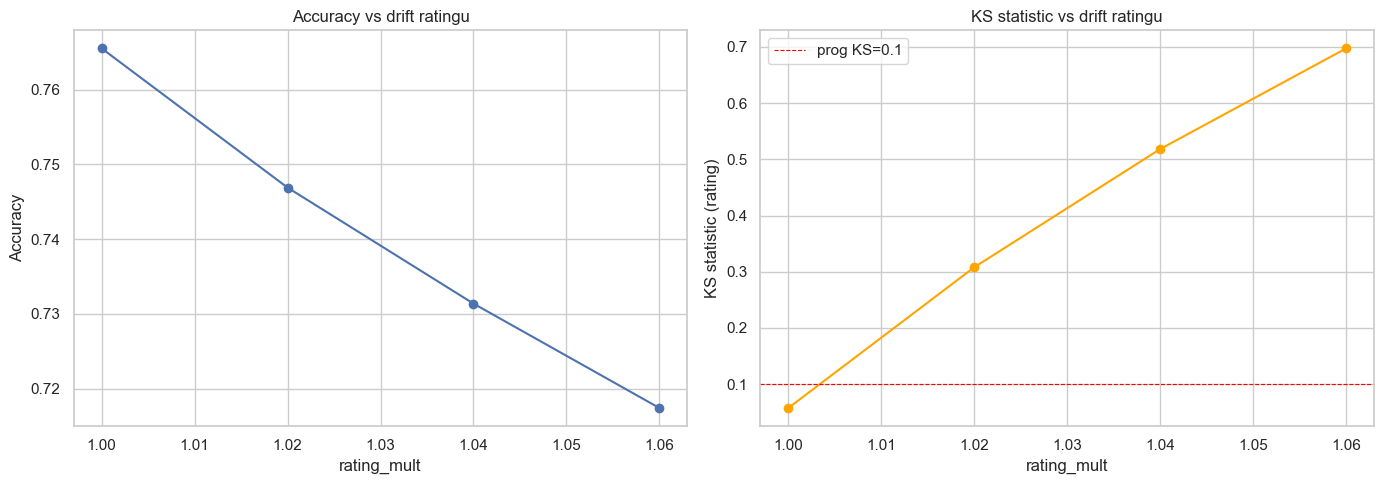

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(drift_df["rating_mult"], drift_df["accuracy"], "o-")
axes[0].set_xlabel("rating_mult")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs drift ratingu")

axes[1].plot(drift_df["rating_mult"], drift_df["ks_stat"], "o-", color="orange")
axes[1].axhline(0.1, color="red", linestyle="--", linewidth=0.8, label="prog KS=0.1")
axes[1].set_xlabel("rating_mult")
axes[1].set_ylabel("KS statistic (rating)")
axes[1].set_title("KS statistic vs drift ratingu")
axes[1].legend()

plt.tight_layout()
plt.show()

Ostatni wiersz tabeli sugeruje zauważalny drift (pvalue bliskie 0.05 lub poniżej) — to sygnał do retrainingu lub alertu.

## 9. Szablon krótkiego raportu

### Cel modelu
Klasyfikacja binarna: przewidywanie, czy wartość rynkowa zawodnika (`market_value`) przekracza medianę dla całego zbioru. Pozwala na automatyczne segmentowanie zawodników na klasy 'high value' i 'low value' na podstawie statystyk sportowych.

### Dane i preprocessing
- Źródło: *European Top Leagues Player Stats 25-26*, Kaggle.
- Merge profili i statystyk → filtr `minutes_played >= 600` → **2573 zawodników**, 8 lig.
- Zmienne per-90 minut wyliczone dla: goals, assists, tackles, interceptions, saves, shots, xG, xA.
- Pipeline: `SimpleImputer(median)` + `StandardScaler` dla cech numerycznych, `OneHotEncoder` dla `position` i `league`.
- Split: 75% train / 25% test, `stratify=y`.

### Wyniki modelu
| Model | Accuracy |
|---|---|
| Baseline (brak skalowania, max_iter=2) | ~0.50 |
| Pipeline (scaling + OHE, max_iter=1000) | ~0.77 |

### Interpretacja (top cechy)
Współczynniki LogReg pokazują, że największy wpływ na predykcję mają:
- `rating` — ogólna ocena zawodnika,
- cechy ligowe (OneHotEncoded) — liga wprost koreluje z poziomem wynagrodzeń i wartości,
- `expected_goals_per90` — potencjał ofensywny.

### Fairness
- Atrybut chroniony: `high_minutes` (zawodnicy z >medianą minut = grupa uprzywilejowana).
- `demographic_parity_diff` ok. -0.19 → zawodnicy z małą liczbą minut są o ~19 pp rzadziej predykowani jako 'high value'.
- `average_odds_diff` ok. -0.12 → model ma gorszą skuteczność dla grupy z mniejszą liczbą minut.
- **Decyzja:** różnice wymagają uwagi — `minutes_played` jest bezpośrednio w features, co powoduje bias. Rozważyć usunięcie `minutes_played` z cech lub użycie wyłącznie wskaźników per-90.

### Drift i monitoring
- KS test train vs test dla kluczowych cech: brak istotnego driftu (p >> 0.05) na oryginalnych danych.
- Symulacja: przy `rating_mult = 1.06` i `goals_shift = +0.15` spada accuracy i rośnie KS stat — sygnał do retrainingu.

### Ograniczenia
- Target arbitralny — oparty o medianę w danym zbiorze (relatywny, nie absolutny).
- Brak danych historycznych — niemożliwy drift czasu rzeczywistego (zbiór z jednego sezonu).
- `market_value` jest skorelowane z ligą (PL > inne ligi) — model może odzwierciedlać bias rynku zamiast umiejętności.
- Brak cech jakościowych (kontuzje, wiek, czas w klubie).